100%|██████████| 12000/12000 [00:00<00:00, 94342.53it/s]


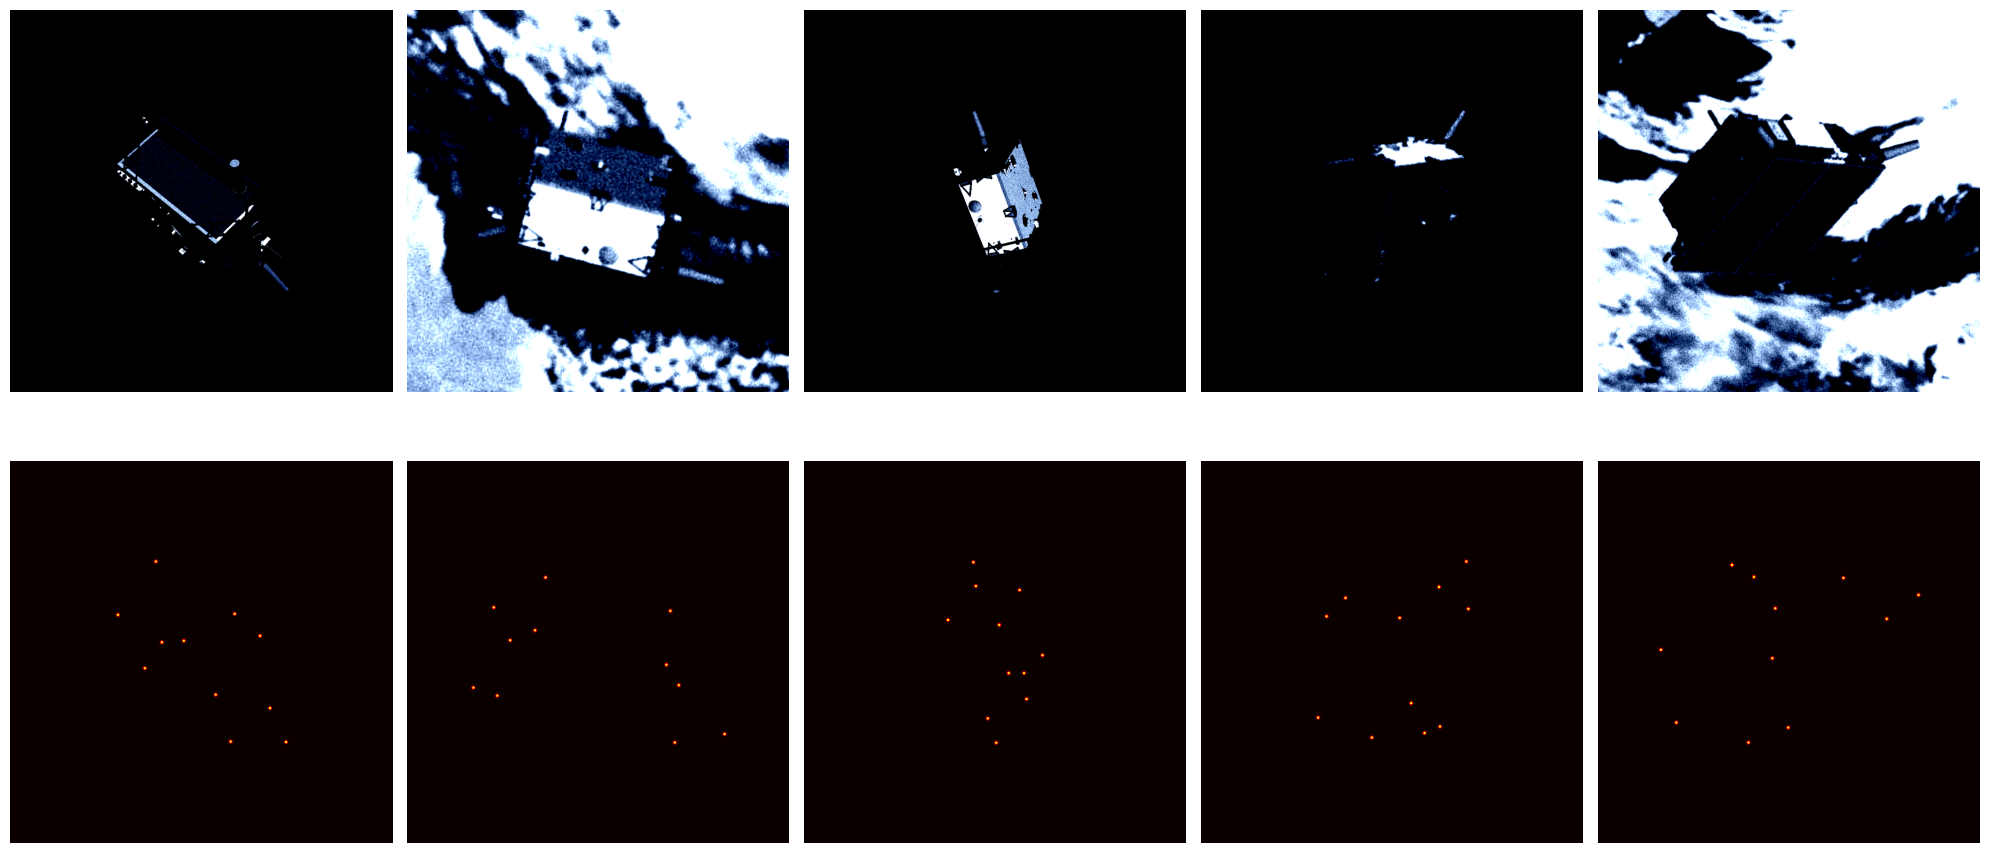

=> init weights from normal distribution
Layer (type:depth-idx)                                       Output Shape              Param #
DataParallel                                                 [1, 11, 768, 768]         --
├─PoseHighResolutionNet: 1-1                                 [1, 11, 768, 768]         28,542,827
├─PoseHighResolutionNet: 1-2                                 --                        --
│    └─Conv2d: 2-1                                           [1, 64, 384, 384]         1,728
│    └─BatchNorm2d: 2-2                                      [1, 64, 384, 384]         128
│    └─ReLU: 2-3                                             [1, 64, 384, 384]         --
│    └─Conv2d: 2-4                                           [1, 64, 192, 192]         36,864
│    └─BatchNorm2d: 2-5                                      [1, 64, 192, 192]         128
│    └─ReLU: 2-6                                             [1, 64, 192, 192]         --
│    └─Sequential: 2-7               

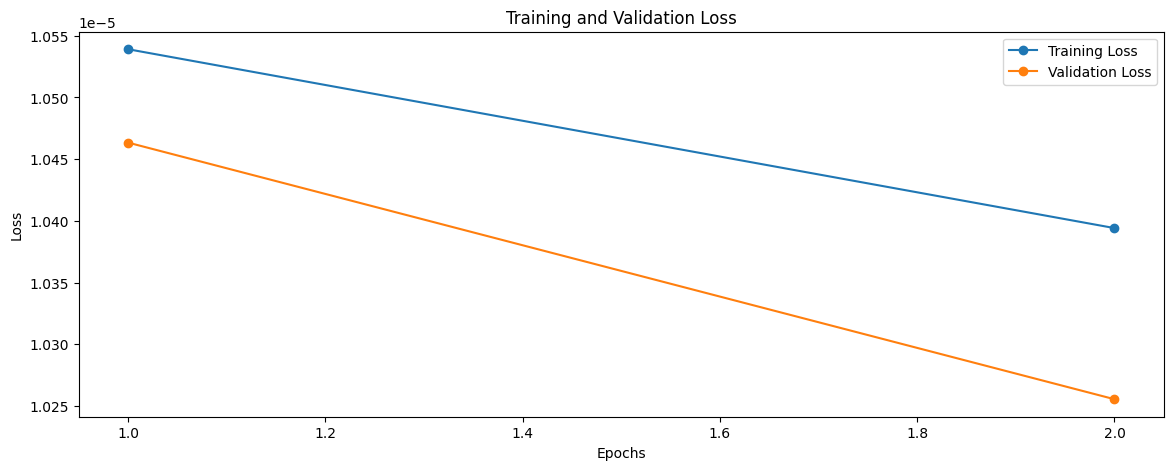

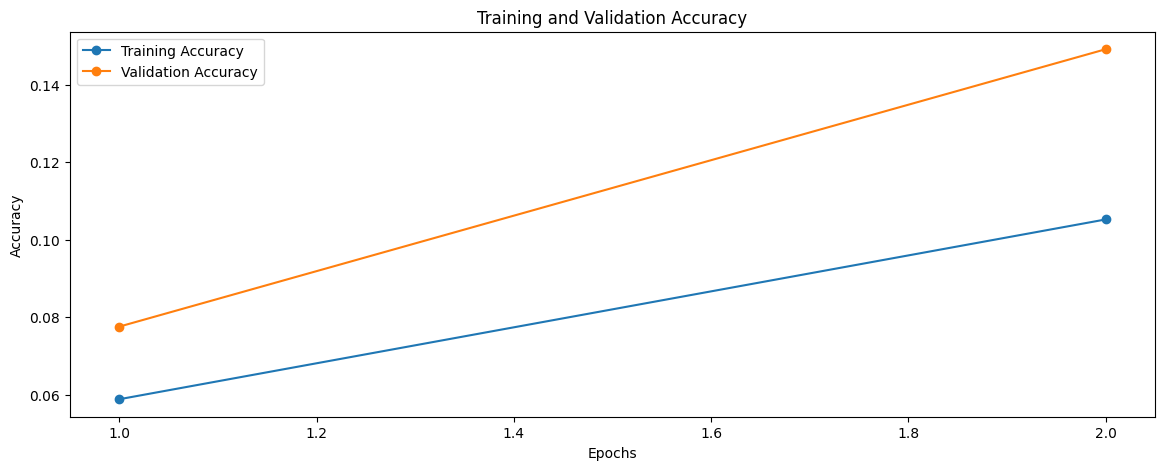

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchinfo import summary
from scipy.io import loadmat
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import numpy as np
import torch.backends.cudnn as cudnn
import cv2
import random

class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, tango_points_dir, camera_matrix_dir, transform=None, is_train=True):
        self.image_width = 1920
        self.image_height = 1200
        self.aspect_ratio = self.image_width * 1.0 / self.image_height
        self.pixel_std = 200
        self.num_joints = 11
        self.image_size = [768,768]
        self.scale_factor = 0.25
        self.rotation_factor = 30
        self.sigma = 2
        self.is_train = is_train
        self.transform = transform

        self.imagesList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir

        self.keypts3d = self.load_tango_3d_keypoints(tango_points_dir) # https://www.desmos.com/3d/jud6lng9gn
        self.cameraMatrix, self.distCoeffs = self.load_camera_intrinsics(camera_matrix_dir)

        with open(self.json_dir, 'r') as f, open("/kaggle/input/mergebochenjsons/merged.json", 'r') as f2:
            annotations = json.load(f)
            bochen_annotations = json.load(f2)
            lookup = { item['filename']: item for item in annotations }
            lookupBochen = { item['image']: item for item in bochen_annotations }
            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup or filename not in lookupBochen:
                    continue
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                bochenbbox = np.array(lookupBochen[filename]['box'], dtype=np.float32)
                bochenjoints = np.array(lookupBochen[filename]['joints'], dtype=np.float32)
                bochenjoints_vis = np.array(lookupBochen[filename]['visible'], dtype=np.float32)

                frame_info = {
                    'frame_idx': frame_idx,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs,
                    'bochenbbox': bochenbbox,
                    'bochenjoints': bochenjoints,
                    'bochenjoints_vis': bochenjoints_vis
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>20:
                #     break

    def __len__(self):
        return len(self.imagesList)
    
    def quat2dcm(self, q):
        """ Computing direction cosine matrix from quaternion, adapted from PyNav.
        Arguments:
            q: (4,) numpy.ndarray - unit quaternion (scalar-first)
        Returns:
            dcm: (3,3) numpy.ndarray - corresponding DCM
        """

        # normalizing quaternion
        q = q / np.linalg.norm(q)

        q0, q1, q2, q3 = q[0], q[1], q[2], q[3]
        dcm = np.zeros((3, 3))
        dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
        dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
        dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2
        dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
        dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2
        dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
        dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1
        dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
        dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

        return dcm

    def load_tango_3d_keypoints(self, mat_dir):
        vertices = loadmat(mat_dir)['tango3Dpoints']
        corners3D = np.transpose(np.array(vertices, dtype=np.float32))
        return corners3D

    def load_camera_intrinsics(self, camera_json):
        with open(camera_json) as f:
            cam = json.load(f)
        cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
        distCoeffs = np.array(cam['distCoeffs'], dtype=np.float32)
        return cameraMatrix, distCoeffs

    def project_keypoints(self, q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
        if keypoints.shape[0] != 3:
            keypoints = np.transpose(keypoints)
        keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))
        pose_mat = np.hstack((np.transpose(self.quat2dcm(q_vbs2tango)),
                              np.expand_dims(r_Vo2To_vbs, 1)))
        xyz = np.dot(pose_mat, keypoints)
        x0, y0 = xyz[0, :] / xyz[2, :], xyz[1, :] / xyz[2, :]
        r2 = x0 * x0 + y0 * y0
        cdist = 1 + distCoeffs[0] * r2 + distCoeffs[1] * r2 * r2 + distCoeffs[4] * r2 * r2 * r2
        x = x0 * cdist + distCoeffs[2] * 2 * x0 * y0 + distCoeffs[3] * (r2 + 2 * x0 * x0)
        y = y0 * cdist + distCoeffs[2] * (r2 + 2 * y0 * y0) + distCoeffs[3] * 2 * x0 * y0
        points2D = np.vstack((cameraMatrix[0, 0] * x + cameraMatrix[0, 2],
                              cameraMatrix[1, 1] * y + cameraMatrix[1, 2]))
        return points2D

    def _box2cs(self, box):
        x, y, w, h = box[:4]
        return self._xywh2cs(x, y, w, h)

    def _xywh2cs(self, x, y, w, h):
        center = np.zeros((2), dtype=np.float32)
        center[0] = x + w * 0.5
        center[1] = y + h * 0.5

        if w > self.aspect_ratio * h:
            h = w * 1.0 / self.aspect_ratio
        elif w < self.aspect_ratio * h:
            w = h * self.aspect_ratio
        scale = np.array(
            [w * 1.0 / self.pixel_std, h * 1.0 / self.pixel_std],
            dtype=np.float32)
        if center[0] != -1:
            scale = scale * 1.25

        return center, scale

    def get_affine_transform(self, center, scale, rot, output_size, shift=np.array([0, 0], dtype=np.float32), inv=0):
        if not isinstance(scale, np.ndarray) and not isinstance(scale, list):
            scale = np.array([scale, scale])
        scale_tmp = scale * 200.0
        src_w = scale_tmp[0]
        dst_w = output_size[0]
        dst_h = output_size[1]
        rot_rad = np.pi * rot / 180
        src_dir = self.get_dir([0, src_w * -0.5], rot_rad)
        dst_dir = np.array([0, dst_w * -0.5], np.float32)
        src = np.zeros((3, 2), dtype=np.float32)
        dst = np.zeros((3, 2), dtype=np.float32)
        src[0, :] = center + scale_tmp * shift
        src[1, :] = center + src_dir + scale_tmp * shift
        dst[0, :] = [dst_w * 0.5, dst_h * 0.5]
        dst[1, :] = np.array([dst_w * 0.5, dst_h * 0.5]) + dst_dir
        src[2:, :] = self.get_3rd_point(src[0, :], src[1, :])
        dst[2:, :] = self.get_3rd_point(dst[0, :], dst[1, :])
        if inv:
            trans = cv2.getAffineTransform(np.float32(dst), np.float32(src))
        else:
            trans = cv2.getAffineTransform(np.float32(src), np.float32(dst))
        return trans

    def affine_transform(self, pt, t):
        new_pt = np.array([pt[0], pt[1], 1.]).T
        new_pt = np.dot(t, new_pt)
        return new_pt[:2]

    def get_3rd_point(self, a, b):
        direct = a - b
        return b + np.array([-direct[1], direct[0]], dtype=np.float32)

    def get_dir(self, src_point, rot_rad):
        sn, cs = np.sin(rot_rad), np.cos(rot_rad)
        src_result = [0, 0]
        src_result[0] = src_point[0] * cs - src_point[1] * sn
        src_result[1] = src_point[0] * sn + src_point[1] * cs
        return src_result

    def generate_target(self, joints, joints_vis, target_type='gaussian', num_joints=11, image_size=np.array([224, 224]), heatmap_size=np.array([224, 224]), sigma=2, use_different_joints_weight=False, joints_weight=1):
        target_weight = np.ones((num_joints, 1), dtype=np.float32)
        target_weight[:, 0] = joints_vis[:, 0]
        assert target_type == 'gaussian', 'Only support gaussian map now!'
        target = np.zeros((num_joints, heatmap_size[1], heatmap_size[0]), dtype=np.float32)
        tmp_size = sigma * 3
        for joint_id in range(num_joints):
            feat_stride = image_size / heatmap_size
            mu_x = int(joints[joint_id][0] / feat_stride[0] + 0.5)
            mu_y = int(joints[joint_id][1] / feat_stride[1] + 0.5)
            ul = [int(mu_x - tmp_size), int(mu_y - tmp_size)]
            br = [int(mu_x + tmp_size + 1), int(mu_y + tmp_size + 1)]
            if ul[0] >= heatmap_size[0] or ul[1] >= heatmap_size[1] or br[0] < 0 or br[1] < 0:
                target_weight[joint_id] = 0
                continue
            size = 2 * tmp_size + 1
            x = np.arange(0, size, 1, np.float32)
            y = x[:, np.newaxis]
            x0 = y0 = size // 2
            g = np.exp(- ((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))
            g_x = max(0, -ul[0]), min(br[0], heatmap_size[0]) - ul[0]
            g_y = max(0, -ul[1]), min(br[1], heatmap_size[1]) - ul[1]
            img_x = max(0, ul[0]), min(br[0], heatmap_size[0])
            img_y = max(0, ul[1]), min(br[1], heatmap_size[1])
            v = target_weight[joint_id]
            if v > 0.5:
                target[joint_id][img_y[0]:img_y[1], img_x[0]:img_x[1]] = g[g_y[0]:g_y[1], g_x[0]:g_x[1]]
        if use_different_joints_weight:
            target_weight = np.multiply(target_weight, joints_weight)
        return target, target_weight
    
    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        data_numpy = cv2.imread(image_path, cv2.IMREAD_COLOR | cv2.IMREAD_IGNORE_ORIENTATION)
        data_numpy = cv2.cvtColor(data_numpy, cv2.COLOR_BGR2RGB)

        q_vbs2tango = self.frameInfoList[idx]['q_vbs2tango']
        r_Vo2To_vbs = self.frameInfoList[idx]['r_Vo2To_vbs']
        bochenbbox = self.frameInfoList[idx]['bochenbbox']
        bochenjoints = self.frameInfoList[idx]['bochenjoints']
        bochenjoints_vis = self.frameInfoList[idx]['bochenjoints_vis']
        # convert bochenjoints to shape (11,3)
        if bochenjoints.shape[1] == 2:
            bochenjoints = np.concatenate(
                [bochenjoints, np.zeros((self.num_joints, 1), dtype=np.float32)],
                axis=1
            )
        # convert bochenjoints_vis to shape (11,3)
        if bochenjoints_vis.ndim == 1:
            bochenjoints_vis = bochenjoints_vis.reshape(-1, 1)
        bo_vis = bochenjoints_vis
        bochenjoints_vis = np.concatenate(
            [bo_vis, bo_vis, np.zeros((self.num_joints, 1), dtype=np.float32)],
            axis=1
        )
        keypts2d = self.project_keypoints(q_vbs2tango, r_Vo2To_vbs,
                                          self.cameraMatrix, self.distCoeffs,
                                          self.keypts3d)  # (2, 11)

        xmin = float(np.min(keypts2d[0]))
        xmax = float(np.max(keypts2d[0]))
        ymin = float(np.min(keypts2d[1]))
        ymax = float(np.max(keypts2d[1]))

        # clamp bbox to image boundaries
        xmin = max(0.0, xmin)
        ymin = max(0.0, ymin)
        xmax = min(self.image_width, xmax)
        ymax = min(self.image_height, ymax)

        box_my = [xmin, ymin, xmax - xmin, ymax - ymin]
        box_bochen = [bochenbbox[0][0], bochenbbox[0][1], bochenbbox[0][2] - bochenbbox[0][0], bochenbbox[0][3] - bochenbbox[0][1]]

        c, s = self._box2cs(box_my)
        c_bochen, s_bochen = self._box2cs(box_bochen)
        r = 0
        r_bochen = 0

        joints_vis = np.zeros((self.num_joints, 3), dtype=np.float32)
        for i in range(self.num_joints):
            x, y = keypts2d[0, i], keypts2d[1, i]
            if xmin <= x <= xmax and ymin <= y <= ymax:
                joints_vis[i, 0] = 1
                joints_vis[i, 1] = 1

        if self.is_train:
            sf = self.scale_factor
            rf = self.rotation_factor
            s = s * np.clip(np.random.randn()*sf + 1, 1 - sf, 1 + sf)
            r = np.clip(np.random.randn()*rf, -rf*2, rf*2) \
                    if random.random() <= 0.6 else 0
            s_bochen = s_bochen * np.clip(np.random.randn()*sf + 1, 1 - sf, 1 + sf)
            r_bochen = np.clip(np.random.randn()*rf, -rf*2, rf*2) \
                    if random.random() <= 0.6 else 0
        
        trans = self.get_affine_transform(c, s, r, self.image_size)
        trans_bochen = self.get_affine_transform(c_bochen, s_bochen, r_bochen, self.image_size)
        image = cv2.warpAffine(
            data_numpy,
            trans,
            (int(self.image_size[0]), int(self.image_size[1])),
            flags=cv2.INTER_LINEAR)
        
        image_bochen = cv2.warpAffine(
            data_numpy,
            trans_bochen,
            (int(self.image_size[0]), int(self.image_size[1])),
            flags=cv2.INTER_LINEAR
        )

        joints = np.concatenate((keypts2d.T, np.zeros((keypts2d.shape[1], 1))), axis=1)  # (11, 3)

        for i in range(self.num_joints):
            if joints_vis[i, 0] > 0.0:
                joints[i, 0:2] = self.affine_transform(joints[i, 0:2], trans)

        for i in range(self.num_joints):
            if bochenjoints_vis[i, 0] > 0.0:
                bochenjoints[i, 0:2] = self.affine_transform(bochenjoints[i, 0:2], trans_bochen)

        for i in range(self.num_joints):
            x, y = joints[i, :2]
            in_frame = 0 <= x < self.image_size[0] and 0 <= y < self.image_size[1]
            joints_vis[i, 0] = 1 if in_frame else 0
            joints_vis[i, 1] = 1 if in_frame else 0


        target, target_weight = self.generate_target(joints, joints_vis, image_size=np.array(self.image_size), heatmap_size=np.array(self.image_size))
        target_bochen, target_weight_bochen = self.generate_target(bochenjoints, bochenjoints_vis, image_size=np.array(self.image_size), heatmap_size=np.array(self.image_size))
        target = torch.tensor(target, dtype=torch.float32)
        target_weight = torch.tensor(target_weight, dtype=torch.float32)
        target_bochen = torch.tensor(target_bochen, dtype=torch.float32)
        target_weight_bochen = torch.tensor(target_weight_bochen, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
            image_bochen = self.transform(image_bochen)

        return image_bochen, target_bochen, target_weight_bochen


train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=1, contrast=1, saturation=1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    )
])

train_dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', tango_points_dir='/kaggle/input/mat-file/tangoPoints.mat', camera_matrix_dir='/kaggle/input/mat-file/camera.json', transform=train_transforms, is_train=True)
val_dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', tango_points_dir='/kaggle/input/mat-file/tangoPoints.mat', camera_matrix_dir='/kaggle/input/mat-file/camera.json', transform=val_transforms, is_train = False)

dataset_size = len(train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

seed = 42                                   
indices = list(range(dataset_size))
random.Random(seed).shuffle(indices) 
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_data = torch.utils.data.Subset(train_dataset, train_indices)
val_data = torch.utils.data.Subset(val_dataset, val_indices)

fig, axes = plt.subplots(2, 5, figsize=(20, 10))  
for i in range(5):
    img_tensor, heatmaps, heatmaps_visible = val_data[i]
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    ax_img = axes[0, i]
    ax_img.imshow(img)
    ax_img.axis('off')

    ax_hm = axes[1, i]
    hm = heatmaps.cpu().numpy()       
    combined = np.max(hm, axis=0)   
    ax_hm.imshow(combined, cmap='hot')
    ax_hm.axis('off')
plt.tight_layout()
plt.show()

BN_MOMENTUM = 0.1
def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1,
                               bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion,
                                  momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class HighResolutionModule(nn.Module):
    def __init__(self, num_branches, blocks, num_blocks, num_inchannels,
                 num_channels, fuse_method, multi_scale_output=True):
        super(HighResolutionModule, self).__init__()
        self._check_branches(
            num_branches, blocks, num_blocks, num_inchannels, num_channels)

        self.num_inchannels = num_inchannels
        self.fuse_method = fuse_method
        self.num_branches = num_branches

        self.multi_scale_output = multi_scale_output

        self.branches = self._make_branches(
            num_branches, blocks, num_blocks, num_channels)
        self.fuse_layers = self._make_fuse_layers()
        self.relu = nn.ReLU(True)

    def _check_branches(self, num_branches, blocks, num_blocks,
                        num_inchannels, num_channels):
        if num_branches != len(num_blocks):
            error_msg = 'NUM_BRANCHES({}) <> NUM_BLOCKS({})'.format(
                num_branches, len(num_blocks))
            print(error_msg)
            raise ValueError(error_msg)

        if num_branches != len(num_channels):
            error_msg = 'NUM_BRANCHES({}) <> NUM_CHANNELS({})'.format(
                num_branches, len(num_channels))
            print(error_msg)
            raise ValueError(error_msg)

        if num_branches != len(num_inchannels):
            error_msg = 'NUM_BRANCHES({}) <> NUM_INCHANNELS({})'.format(
                num_branches, len(num_inchannels))
            print(error_msg)
            raise ValueError(error_msg)

    def _make_one_branch(self, branch_index, block, num_blocks, num_channels,
                         stride=1):
        downsample = None
        if stride != 1 or \
           self.num_inchannels[branch_index] != num_channels[branch_index] * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.num_inchannels[branch_index],
                    num_channels[branch_index] * block.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(
                    num_channels[branch_index] * block.expansion,
                    momentum=BN_MOMENTUM
                ),
            )

        layers = []
        layers.append(
            block(
                self.num_inchannels[branch_index],
                num_channels[branch_index],
                stride,
                downsample
            )
        )
        self.num_inchannels[branch_index] = \
            num_channels[branch_index] * block.expansion
        for i in range(1, num_blocks[branch_index]):
            layers.append(
                block(
                    self.num_inchannels[branch_index],
                    num_channels[branch_index]
                )
            )

        return nn.Sequential(*layers)

    def _make_branches(self, num_branches, block, num_blocks, num_channels):
        branches = []

        for i in range(num_branches):
            branches.append(
                self._make_one_branch(i, block, num_blocks, num_channels)
            )

        return nn.ModuleList(branches)

    def _make_fuse_layers(self):
        if self.num_branches == 1:
            return None

        num_branches = self.num_branches
        num_inchannels = self.num_inchannels
        fuse_layers = []
        for i in range(num_branches if self.multi_scale_output else 1):
            fuse_layer = []
            for j in range(num_branches):
                if j > i:
                    fuse_layer.append(
                        nn.Sequential(
                            nn.Conv2d(
                                num_inchannels[j],
                                num_inchannels[i],
                                1, 1, 0, bias=False
                            ),
                            nn.BatchNorm2d(num_inchannels[i]),
                            nn.Upsample(scale_factor=2**(j-i), mode='nearest')
                        )
                    )
                elif j == i:
                    fuse_layer.append(None)
                else:
                    conv3x3s = []
                    for k in range(i-j):
                        if k == i - j - 1:
                            num_outchannels_conv3x3 = num_inchannels[i]
                            conv3x3s.append(
                                nn.Sequential(
                                    nn.Conv2d(
                                        num_inchannels[j],
                                        num_outchannels_conv3x3,
                                        3, 2, 1, bias=False
                                    ),
                                    nn.BatchNorm2d(num_outchannels_conv3x3)
                                )
                            )
                        else:
                            num_outchannels_conv3x3 = num_inchannels[j]
                            conv3x3s.append(
                                nn.Sequential(
                                    nn.Conv2d(
                                        num_inchannels[j],
                                        num_outchannels_conv3x3,
                                        3, 2, 1, bias=False
                                    ),
                                    nn.BatchNorm2d(num_outchannels_conv3x3),
                                    nn.ReLU(True)
                                )
                            )
                    fuse_layer.append(nn.Sequential(*conv3x3s))
            fuse_layers.append(nn.ModuleList(fuse_layer))

        return nn.ModuleList(fuse_layers)

    def get_num_inchannels(self):
        return self.num_inchannels

    def forward(self, x):
        if self.num_branches == 1:
            return [self.branches[0](x[0])]

        for i in range(self.num_branches):
            x[i] = self.branches[i](x[i])

        x_fuse = []

        for i in range(len(self.fuse_layers)):
            y = x[0] if i == 0 else self.fuse_layers[i][0](x[0])
            for j in range(1, self.num_branches):
                if i == j:
                    y = y + x[j]
                else:
                    y = y + self.fuse_layers[i][j](x[j])
            x_fuse.append(self.relu(y))

        return x_fuse


blocks_dict = {
    'BASIC': BasicBlock,
    'BOTTLENECK': Bottleneck
}


class PoseHighResolutionNet(nn.Module):

    def __init__(self, cfg, **kwargs):
        self.inplanes = 64
        extra = cfg["MODEL"]["EXTRA"]
        super(PoseHighResolutionNet, self).__init__()

        # stem net
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=BN_MOMENTUM)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1,
                               bias=False)
        self.bn2 = nn.BatchNorm2d(64, momentum=BN_MOMENTUM)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(Bottleneck, 64, 4)

        self.stage2_cfg = cfg['MODEL']['EXTRA']['STAGE2']
        num_channels = self.stage2_cfg['NUM_CHANNELS']
        block = blocks_dict[self.stage2_cfg['BLOCK']]
        num_channels = [
            num_channels[i] * block.expansion for i in range(len(num_channels))
        ]
        self.transition1 = self._make_transition_layer([256], num_channels)
        self.stage2, pre_stage_channels = self._make_stage(
            self.stage2_cfg, num_channels)

        self.stage3_cfg = cfg['MODEL']['EXTRA']['STAGE3']
        num_channels = self.stage3_cfg['NUM_CHANNELS']
        block = blocks_dict[self.stage3_cfg['BLOCK']]
        num_channels = [
            num_channels[i] * block.expansion for i in range(len(num_channels))
        ]
        self.transition2 = self._make_transition_layer(
            pre_stage_channels, num_channels)
        self.stage3, pre_stage_channels = self._make_stage(
            self.stage3_cfg, num_channels)

        self.stage4_cfg = cfg['MODEL']['EXTRA']['STAGE4']
        num_channels = self.stage4_cfg['NUM_CHANNELS']
        block = blocks_dict[self.stage4_cfg['BLOCK']]
        num_channels = [
            num_channels[i] * block.expansion for i in range(len(num_channels))
        ]
        self.transition3 = self._make_transition_layer(
            pre_stage_channels, num_channels)
        self.stage4, pre_stage_channels = self._make_stage(
            self.stage4_cfg, num_channels, multi_scale_output=False)
        
        self.final_layer = nn.Sequential(
	    nn.Conv2d(
       	    in_channels=pre_stage_channels[0],
            out_channels=32,
    	    kernel_size=extra["FINAL_CONV_KERNEL"],  
            stride=1,
            padding=1 if extra["FINAL_CONV_KERNEL"] == 3 else 0  
        ),  
	    nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride = 2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, cfg["MODEL"]["NUM_JOINTS"], 3, stride=2, padding=1, output_padding=1),
        )

        self.pretrained_layers = cfg['MODEL']['EXTRA']['PRETRAINED_LAYERS']

    def _make_transition_layer(
            self, num_channels_pre_layer, num_channels_cur_layer):
        num_branches_cur = len(num_channels_cur_layer)
        num_branches_pre = len(num_channels_pre_layer)

        transition_layers = []
        for i in range(num_branches_cur):
            if i < num_branches_pre:
                if num_channels_cur_layer[i] != num_channels_pre_layer[i]:
                    transition_layers.append(
                        nn.Sequential(
                            nn.Conv2d(
                                num_channels_pre_layer[i],
                                num_channels_cur_layer[i],
                                3, 1, 1, bias=False
                            ),
                            nn.BatchNorm2d(num_channels_cur_layer[i]),
                            nn.ReLU(inplace=True)
                        )
                    )
                else:
                    transition_layers.append(None)
            else:
                conv3x3s = []
                for j in range(i+1-num_branches_pre):
                    inchannels = num_channels_pre_layer[-1]
                    outchannels = num_channels_cur_layer[i] \
                        if j == i-num_branches_pre else inchannels
                    conv3x3s.append(
                        nn.Sequential(
                            nn.Conv2d(
                                inchannels, outchannels, 3, 2, 1, bias=False
                            ),
                            nn.BatchNorm2d(outchannels),
                            nn.ReLU(inplace=True)
                        )
                    )
                transition_layers.append(nn.Sequential(*conv3x3s))

        return nn.ModuleList(transition_layers)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.inplanes, planes * block.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(planes * block.expansion, momentum=BN_MOMENTUM),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def _make_stage(self, layer_config, num_inchannels,
                    multi_scale_output=True):
        num_modules = layer_config['NUM_MODULES']
        num_branches = layer_config['NUM_BRANCHES']
        num_blocks = layer_config['NUM_BLOCKS']
        num_channels = layer_config['NUM_CHANNELS']
        block = blocks_dict[layer_config['BLOCK']]
        fuse_method = layer_config['FUSE_METHOD']

        modules = []
        for i in range(num_modules):
            # multi_scale_output is only used last module
            if not multi_scale_output and i == num_modules - 1:
                reset_multi_scale_output = False
            else:
                reset_multi_scale_output = True

            modules.append(
                HighResolutionModule(
                    num_branches,
                    block,
                    num_blocks,
                    num_inchannels,
                    num_channels,
                    fuse_method,
                    reset_multi_scale_output
                )
            )
            num_inchannels = modules[-1].get_num_inchannels()

        return nn.Sequential(*modules), num_inchannels

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.layer1(x)

        x_list = []
        for i in range(self.stage2_cfg['NUM_BRANCHES']):
            if self.transition1[i] is not None:
                x_list.append(self.transition1[i](x))
            else:
                x_list.append(x)
        y_list = self.stage2(x_list)

        x_list = []
        for i in range(self.stage3_cfg['NUM_BRANCHES']):
            if self.transition2[i] is not None:
                x_list.append(self.transition2[i](y_list[-1]))
            else:
                x_list.append(y_list[i])
        y_list = self.stage3(x_list)

        x_list = []
        for i in range(self.stage4_cfg['NUM_BRANCHES']):
            if self.transition3[i] is not None:
                x_list.append(self.transition3[i](y_list[-1]))
            else:
                x_list.append(y_list[i])
        y_list = self.stage4(x_list)

        x = self.final_layer(y_list[0])

        return x

    def init_weights(self, pretrained=''):
        print('=> init weights from normal distribution')
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.normal_(m.weight, std=0.001)
                for name, _ in m.named_parameters():
                    if name in ['bias']:
                        nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.ConvTranspose2d):
                nn.init.normal_(m.weight, std=0.001)
                for name, _ in m.named_parameters():
                    if name in ['bias']:
                        nn.init.constant_(m.bias, 0)

        if os.path.isfile(pretrained):
            pretrained_state_dict = torch.load(pretrained)
            print('=> loading pretrained model {}'.format(pretrained))

            need_init_state_dict = {}
            for name, m in pretrained_state_dict.items():
                if name.split('.')[0] in self.pretrained_layers \
                   or self.pretrained_layers[0] == '*':
                    need_init_state_dict[name] = m
            self.load_state_dict(need_init_state_dict, strict=False)
        elif pretrained:
            print('=> please download pre-trained models first!')
            raise ValueError('{} is not exist!'.format(pretrained))


class JointsMSELoss(nn.Module):
    def __init__(self, use_target_weight = True):
        super(JointsMSELoss, self).__init__()
        self.criterion = nn.MSELoss(reduction='mean')
        self.use_target_weight = use_target_weight

    def forward(self, output, target, target_weight):
        batch_size = output.size(0)
        num_joints = output.size(1)
        heatmaps_pred = output.reshape((batch_size, num_joints, -1)).split(1, 1)
        heatmaps_gt = target.reshape((batch_size, num_joints, -1)).split(1, 1)
        loss = 0

        for idx in range(num_joints):
            heatmap_pred = heatmaps_pred[idx].squeeze()
            heatmap_gt = heatmaps_gt[idx].squeeze()
            if self.use_target_weight:
                loss += 0.5 * self.criterion(
                    heatmap_pred.mul(target_weight[:, idx]),
                    heatmap_gt.mul(target_weight[:, idx])
                )
            else:
                loss += 0.5 * self.criterion(heatmap_pred, heatmap_gt)

        return loss / num_joints

def get_max_preds(batch_heatmaps):
    '''
    get predictions from score maps
    heatmaps: numpy.ndarray([batch_size, num_joints, height, width])
    '''
    assert isinstance(batch_heatmaps, np.ndarray), \
        'batch_heatmaps should be numpy.ndarray'
    assert batch_heatmaps.ndim == 4, 'batch_images should be 4-ndim'

    batch_size = batch_heatmaps.shape[0]
    num_joints = batch_heatmaps.shape[1]
    width = batch_heatmaps.shape[3]
    heatmaps_reshaped = batch_heatmaps.reshape((batch_size, num_joints, -1))
    idx = np.argmax(heatmaps_reshaped, 2)
    maxvals = np.amax(heatmaps_reshaped, 2)

    maxvals = maxvals.reshape((batch_size, num_joints, 1))
    idx = idx.reshape((batch_size, num_joints, 1))

    preds = np.tile(idx, (1, 1, 2)).astype(np.float32)

    preds[:, :, 0] = (preds[:, :, 0]) % width
    preds[:, :, 1] = np.floor((preds[:, :, 1]) / width)

    pred_mask = np.tile(np.greater(maxvals, 0.0), (1, 1, 2))
    pred_mask = pred_mask.astype(np.float32)

    preds *= pred_mask
    return preds, maxvals

def calc_dists(preds, target, normalize):
    preds = preds.astype(np.float32)
    target = target.astype(np.float32)
    dists = np.zeros((preds.shape[1], preds.shape[0]))
    for n in range(preds.shape[0]):
        for c in range(preds.shape[1]):
            if target[n, c, 0] > 1 and target[n, c, 1] > 1:
                normed_preds = preds[n, c, :] / normalize[n]
                normed_targets = target[n, c, :] / normalize[n]
                dists[c, n] = np.linalg.norm(normed_preds - normed_targets)
            else:
                dists[c, n] = -1
    return dists

def dist_acc(dists, thr=0.5):
    ''' Return percentage below threshold while ignoring values with a -1 '''
    dist_cal = np.not_equal(dists, -1)
    num_dist_cal = dist_cal.sum()
    if num_dist_cal > 0:
        return np.less(dists[dist_cal], thr).sum() * 1.0 / num_dist_cal
    else:
        return -1
    
def accuracy(output, target, hm_type='gaussian', thr=0.5):
    '''
    Calculate accuracy according to PCK,
    but uses ground truth heatmap rather than x,y locations
    First value to be returned is average accuracy across 'idxs',
    followed by individual accuracies
    '''
    idx = list(range(output.shape[1]))
    norm = 1.0
    if hm_type == 'gaussian':
        pred, _ = get_max_preds(output)
        target, _ = get_max_preds(target)
        h = output.shape[2]
        w = output.shape[3]
        norm = np.ones((pred.shape[0], 2)) * np.array([h, w]) / 10
    dists = calc_dists(pred, target, norm)

    acc = np.zeros((len(idx) + 1))
    avg_acc = 0
    cnt = 0

    for i in range(len(idx)):
        acc[i + 1] = dist_acc(dists[idx[i]])
        if acc[i + 1] >= 0:
            avg_acc = avg_acc + acc[i + 1]
            cnt += 1

    avg_acc = avg_acc / cnt if cnt != 0 else 0
    if cnt != 0:
        acc[0] = avg_acc
    return acc, avg_acc, cnt, pred

def save_checkpoint(states, is_best, output_dir,
                    filename='checkpoint.pth'):
    torch.save(states, os.path.join(output_dir, filename))
    if is_best and 'state_dict' in states:
        torch.save(states['best_state_dict'],
                   os.path.join(output_dir, 'model_best.pth'))


def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    train_accuracy_tot = 0
    for batch,(X, Y_targets, Y_targets_weights ) in enumerate(train_dataloader):
        X, Y_targets, Y_targets_weights = X.to(device), Y_targets.to(device), Y_targets_weights.to(device)
        model.train()
        optimizer.zero_grad()

        heatmaps_pred = model(X)
        loss = loss_fn(heatmaps_pred, Y_targets, Y_targets_weights)
        loss.backward()
        optimizer.step()

        loss_tot += loss.item()
        _, avg_acc, cnt, pred = accuracy(heatmaps_pred.detach().cpu().numpy(), Y_targets.detach().cpu().numpy())
        train_accuracy_tot += avg_acc
        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>10.9f} - Training Accuracy: {avg_acc:.5f}  [{current:>5d}/{train_size:>5d}]", end="")

    scheduler.step()  
    loss_avg = loss_tot / num_batches
    train_accuracy_tot_avg = train_accuracy_tot / num_batches
    val_loss = 0
    val_accuracy_tot = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, Y_targets, Y_targets_weights) in enumerate(val_dataloader):
            X, Y_targets, Y_targets_weights = X.to(device), Y_targets.to(device), Y_targets_weights.to(device)
            heatmaps_pred = model(X)
            _, avg_acc, cnt, pred = accuracy(heatmaps_pred.cpu().numpy(), Y_targets.cpu().numpy())
            loss = loss_fn(heatmaps_pred, Y_targets, Y_targets_weights)
            val_loss += loss
            val_accuracy_tot += avg_acc
            current = batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>10.9f} - Validation loss: {loss:>10.9f} - Training Accuracy: {train_accuracy_tot_avg} - Validation Accuracy: {avg_acc}  [{batch * batch_size + len(X):>5d}/{len(val_dataloader.dataset):>5d}]", end="")

    val_loss /= len(val_dataloader)
    val_accuracy_tot_avg = val_accuracy_tot / len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>10.9f} - Validation loss: {val_loss:>10.9f} - Training Accuracy: {train_accuracy_tot_avg:.5f} - Validation Accuracy: {val_accuracy_tot_avg:.5f}                                                   ")
    print(end='')
    return loss_avg, val_loss.cpu(), train_accuracy_tot_avg, val_accuracy_tot_avg

POSE_HIGH_RESOLUTION_NET = {
    "PRETRAINED_LAYERS": [
        'conv1', 'bn1', 'conv2', 'bn2', 'layer1', 
        'transition1', 'stage2', 'transition2', 
        'stage3', 'transition3', 'stage4'
    ],
    "FINAL_CONV_KERNEL": 1,
    "STAGE2": {
        "NUM_MODULES": 1,
        "NUM_BRANCHES": 2,
        "BLOCK": 'BASIC',
        "NUM_BLOCKS": [4, 4],
        "NUM_CHANNELS": [32, 64],
        "FUSE_METHOD": 'SUM'
    },
    "STAGE3": {
        "NUM_MODULES": 4,
        "NUM_BRANCHES": 3,
        "BLOCK": 'BASIC',
        "NUM_BLOCKS": [4, 4, 4],
        "NUM_CHANNELS": [32, 64, 128],
        "FUSE_METHOD": 'SUM'
    },
    "STAGE4": {
        "NUM_MODULES": 3,
        "NUM_BRANCHES": 4,
        "BLOCK": 'BASIC',
        "NUM_BLOCKS": [4, 4, 4, 4],
        "NUM_CHANNELS": [32, 64, 128, 256],
        "FUSE_METHOD": 'SUM'
    }
}

cfg = {
    "MODEL": {
        "EXTRA": POSE_HIGH_RESOLUTION_NET,
        "NUM_JOINTS": 11  
    }
}


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.enabled = True

model = PoseHighResolutionNet(cfg).to(device)
model = torch.nn.DataParallel(model)
model.module.init_weights()


learning_rate = 1e-3
batch_size = 10
num_of_epochs = 2
loss_fn = JointsMSELoss().to(device)
input_dir = '/kaggle/input/bochenkeypointdtu'
output_dir = '/kaggle/working/'

best_perf = 0.0
best_model = False
last_epoch = -1
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
begin_epoch = 0
checkpoint_file = os.path.join(input_dir, 'checkpoint.pth')

if os.path.isfile(checkpoint_file):
    checkpoint = torch.load(checkpoint_file, weights_only=False) 
    begin_epoch = checkpoint['epoch']
    best_perf = checkpoint['perf']
    last_epoch = checkpoint['epoch']
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    print(f"Loaded checkpoint : {checkpoint_file} at epoch {begin_epoch}")


scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, [120,170], 0.1, last_epoch=last_epoch)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)

print(summary(model, (1,3,768,768)))

loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}

best_val_loss = float('inf')

for t in range(begin_epoch, begin_epoch + num_of_epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss, train_accuracy, val_accuracy = train_loop(train_dataloader, validation_dataloader, model, loss_fn, optimizer, batch_size, t)
    loss_history['train'].append(float(train_loss))
    loss_history['val'].append(float(val_loss))
    acc_history['train'].append(float(train_accuracy))
    acc_history['val'].append(float(val_accuracy))
    
    if (t + 1) % 1 == 0:
        save_checkpoint({
            'epoch': t + 1,
            'model': "PoseHighResolutionNet",
            'state_dict': model.state_dict(),
            'best_state_dict': model.state_dict(),
            'perf': val_accuracy,
            'optimizer': optimizer.state_dict(),
        }, True, output_dir)
        

plt.figure(figsize=(14, 5))
eplist=[]
for i in range(begin_epoch, begin_epoch + num_of_epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], 'o-', label='Training Loss')  
plt.plot(eplist, loss_history['val'], 'o-', label='Validation Loss') 
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(eplist, acc_history['train'], 'o-', label='Training Accuracy')
plt.plot(eplist, acc_history['val'], 'o-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()